# MA(q) Parameter Estimation

The moving average model of order $q$, denoted by $\text{MA}(q)$, is defined by,

$
\begin{align}
X_t = \sum_{i=1}^q \vartheta_i \varepsilon_{t-i} + \varepsilon_t
\end{align}
\tag{1}
$

where $\varepsilon_t$ are independent and identically distributed random variables with distribution,

$
\begin{align}
\varepsilon_i \sim \text{Normal}(0, \sigma)
\end{align}
\tag{2}
$

It follows that,

$
\begin{align}
&\text{E}[\varepsilon_t] = 0 \\
&\text{E}[\varepsilon_t^2] = \sigma^2 \\
&\text{E}[\varepsilon_t \varepsilon_s] = \delta_{ts} \sigma^2
\end{align}
\tag{3}
$

Here the $\vartheta_i$ are estimated given an $MA(q)$ time series. 

## Includes

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import arima
from lib.plots import stack, fpoints, fcurve
from lib.utils import create_parameter_scan

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [2]:
nsample = 1000

def comparison_plot(θ_vals, title, ylim, *params):
    labels = [f"θ={val}" for val in θ_vals] 
    ylabels = r"$S_t$"
    source = lambda **kwargs : arima.create_ma_source(**kwargs)
    t, scan = create_parameter_scan(source, *params)
    stack(scan, t, ylim=ylim, title=title, labels=labels, ylabels=ylabels, xlabel="Time", figsize=(10, 6))
    return t, scan

## Simulations ($\sigma = 1$)

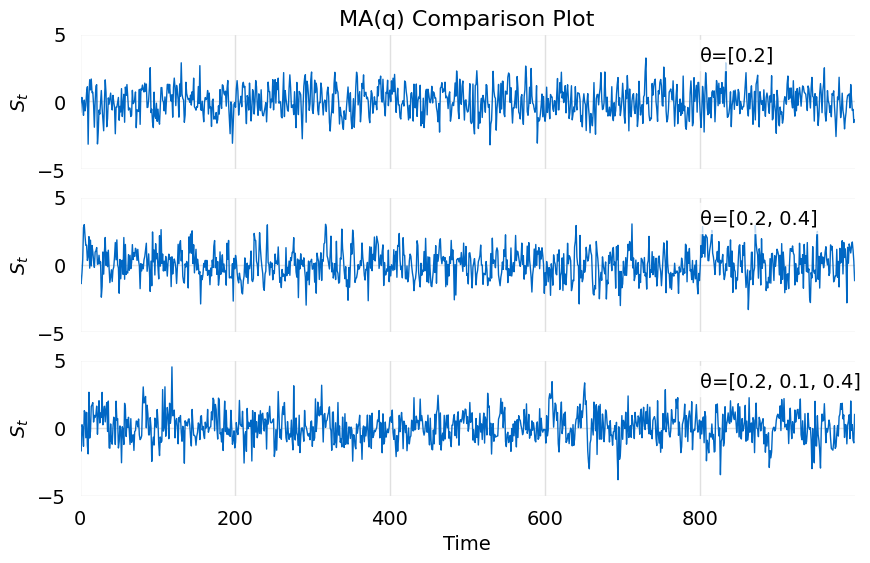

In [3]:
nsample = 1000
σ = 1.0
θ_vals = [[0.2], [0.2, 0.4], [0.2, 0.1, 0.4]]
params = [{"θ": θ, "σ": σ, "npts": nsample} for θ in θ_vals]
title = "MA(q) Comparison Plot"
t, scan = comparison_plot(θ_vals, title, (-5.0, 5.0), *params)

## Estimation of $\text{MA}(q)$ Parameters

$\text{MA}(q)$ parameters are estimated using `statsmodels.tsa.arima_model.ARMA`

### $\text{MA}(1)$ Example ($\varphi = 0.2$)

In [4]:
result, result_model = arima.compute_ma_estimate(scan[0], order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(0, 0, 1)   Log Likelihood               -1430.118
Date:                Sun, 23 Jul 2023   AIC                           2866.236
Time:                        11:22:56   BIC                           2880.960
Sample:                             0   HQIC                          2871.832
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0002      0.041     -0.005      0.996      -0.080       0.080
ma.L1          0.2767      0.031      8.816      0.000       0.215       0.338
sigma2         1.0225      0.048     21.493      0.000       0.929       1.116
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 1.42
Prob(Q):                              0.97   Prob(JB):                         0.49
Heteroskedasticity (H):               0.98   Skew:                            -0.06
Prob(H) (two-sided):                  0.85   Kurtosis:                         2.86
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [5]:
result_model.dict

{'est_model': 'ARMA',
 'arma_est_type': 'MA',
 'order': 1,
 'const': {'Estimate': -0.00020813540130077047,
  'Error': 0.04082665130189095,
  'Estimate Label': '$\\hat{\\mu^*}$',
  'Error Label': '$\\sigma_{\\hat{\\mu^*}}$'},
 'sigma2': {'Estimate': 1.0225183958914634,
  'Error': 0.04757425399011622,
  'Estimate Label': '$\\hat{\\sigma^2}$',
  'Error Label': '$\\sigma_{\\hat{\\sigma^2}}$'},
 'params': [{'Estimate': 0.2766899231515472,
   'Error': 0.03138337164064133,
   'Estimate Label': '$\\hat{\\theta_{0}}$',
   'Error Label': '$\\sigma_{$\\hat{\theta_{0}}}$'}]}

### $\text{MA}(2)$ Example ($\varphi = [0.2, 0.4]$)

In [6]:
result, result_model = arima.compute_ma_estimate(scan[1], order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(0, 0, 2)   Log Likelihood               -1414.395
Date:                Sun, 23 Jul 2023   AIC                           2836.790
Time:                        11:22:57   BIC                           2856.421
Sample:                             0   HQIC                          2844.251
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0078      0.051     -0.155      0.877      -0.107       0.091
ma.L1          0.2070      0.030      7.006      0.000       0.149       0.265
ma.L2          0.3979      0.031     12.738      0.000       0.337       0.459
sigma2         0.9906      0.043     22.908      0.000       0.906       1.075
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 0.61
Prob(Q):                              1.00   Prob(JB):                         0.74
Heteroskedasticity (H):               1.15   Skew:                             0.03
Prob(H) (two-sided):                  0.20   Kurtosis:                         3.11
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [7]:
result_model.dict

{'est_model': 'ARMA',
 'arma_est_type': 'MA',
 'order': 2,
 'const': {'Estimate': -0.007844588063878983,
  'Error': 0.050534782084725706,
  'Estimate Label': '$\\hat{\\mu^*}$',
  'Error Label': '$\\sigma_{\\hat{\\mu^*}}$'},
 'sigma2': {'Estimate': 0.990605136924318,
  'Error': 0.04324215792460397,
  'Estimate Label': '$\\hat{\\sigma^2}$',
  'Error Label': '$\\sigma_{\\hat{\\sigma^2}}$'},
 'params': [{'Estimate': 0.20700032569138774,
   'Error': 0.029545396116322137,
   'Estimate Label': '$\\hat{\\theta_{0}}$',
   'Error Label': '$\\sigma_{$\\hat{\theta_{0}}}$'},
  {'Estimate': 0.3979310669888028,
   'Error': 0.03124058922592718,
   'Estimate Label': '$\\hat{\\theta_{1}}$',
   'Error Label': '$\\sigma_{$\\hat{\theta_{1}}}$'}]}

### $\text{MA}(3)$ Example ($\varphi = [0.2, 0.1, 0.4]$)

In [8]:
result, result_model = arima.compute_ma_estimate(scan[2], order=3)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(0, 0, 3)   Log Likelihood               -1416.901
Date:                Sun, 23 Jul 2023   AIC                           2843.802
Time:                        11:22:57   BIC                           2868.341
Sample:                             0   HQIC                          2853.129
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0647      0.053      1.219      0.223      -0.039       0.169
ma.L1          0.1998      0.029      6.957      0.000       0.144       0.256
ma.L2          0.1156      0.030      3.845      0.000       0.057       0.175
ma.L3          0.3635      0.030     12.205      0.000       0.305       0.422
sigma2         0.9955      0.044     22.580      0.000       0.909       1.082
===================================================================================
Ljung-Box (L1) (Q):                   0.12   Jarque-Bera (JB):                 0.48
Prob(Q):                              0.73   Prob(JB):                         0.79
Heteroskedasticity (H):               0.95   Skew:                             0.03
Prob(H) (two-sided):                  0.61   Kurtosis:                         3.09
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [9]:
result_model.dict

{'est_model': 'ARMA',
 'arma_est_type': 'MA',
 'order': 3,
 'const': {'Estimate': 0.0646813154622762,
  'Error': 0.05304732678498678,
  'Estimate Label': '$\\hat{\\mu^*}$',
  'Error Label': '$\\sigma_{\\hat{\\mu^*}}$'},
 'sigma2': {'Estimate': 0.9954815900649269,
  'Error': 0.04408663156071233,
  'Estimate Label': '$\\hat{\\sigma^2}$',
  'Error Label': '$\\sigma_{\\hat{\\sigma^2}}$'},
 'params': [{'Estimate': 0.19982619503485843,
   'Error': 0.02872318293403421,
   'Estimate Label': '$\\hat{\\theta_{0}}$',
   'Error Label': '$\\sigma_{$\\hat{\theta_{0}}}$'},
  {'Estimate': 0.11560803214131513,
   'Error': 0.030066765578658373,
   'Estimate Label': '$\\hat{\\theta_{1}}$',
   'Error Label': '$\\sigma_{$\\hat{\theta_{1}}}$'},
  {'Estimate': 0.36345704002274465,
   'Error': 0.029779900867239407,
   'Estimate Label': '$\\hat{\\theta_{2}}$',
   'Error Label': '$\\sigma_{$\\hat{\theta_{2}}}$'}]}

## Simulations ($\sigma = 5$)

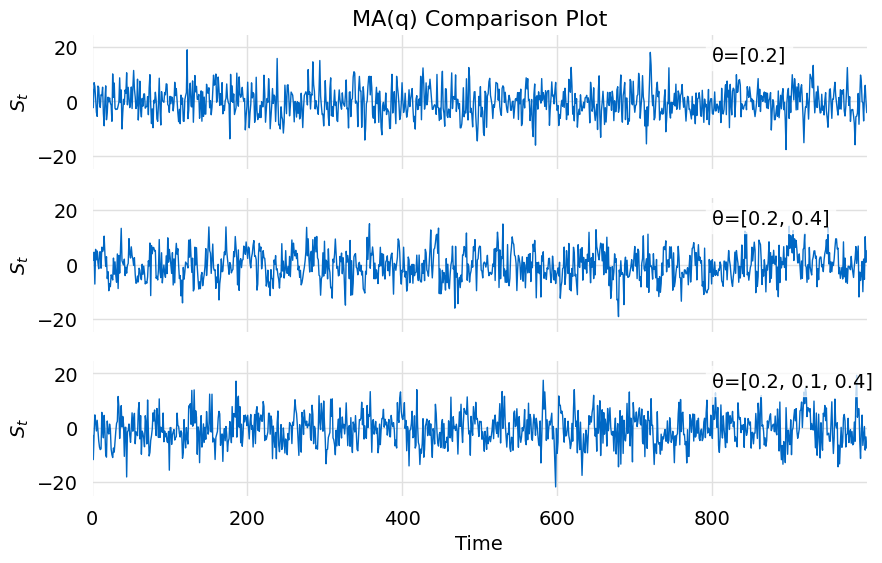

In [10]:
nsample = 1000
σ = 5.0
θ_vals = [[0.2], [0.2, 0.4], [0.2, 0.1, 0.4]]
params = [{"θ": θ, "σ": σ, "npts": nsample} for θ in θ_vals]
title = "MA(q) Comparison Plot"
t, scan = comparison_plot(θ_vals, title, (-25.0, 25.0), *params)

## Estimation of $\text{MA}(q)$ Parameters

$\text{MA}(q)$ parameters are estimated using `statsmodels.tsa.arima_model.ARMA`

### $\text{MA}(1)$ Example ($\varphi = 0.2$)

In [11]:
result, result_model = arima.compute_ma_estimate(scan[0], order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(0, 0, 1)   Log Likelihood               -3045.137
Date:                Sun, 23 Jul 2023   AIC                           6096.274
Time:                        11:22:57   BIC                           6110.997
Sample:                             0   HQIC                          6101.870
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.2025      0.201     -1.005      0.315      -0.597       0.192
ma.L1          0.2511      0.030      8.326      0.000       0.192       0.310
sigma2        25.8527      1.123     23.016      0.000      23.651      28.054
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):                 1.35
Prob(Q):                              0.85   Prob(JB):                         0.51
Heteroskedasticity (H):               0.92   Skew:                             0.06
Prob(H) (two-sided):                  0.44   Kurtosis:                         3.14
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [12]:
result_model.dict

{'est_model': 'ARMA',
 'arma_est_type': 'MA',
 'order': 1,
 'const': {'Estimate': -0.20245288945416617,
  'Error': 0.20138145415825304,
  'Estimate Label': '$\\hat{\\mu^*}$',
  'Error Label': '$\\sigma_{\\hat{\\mu^*}}$'},
 'sigma2': {'Estimate': 25.852726519782102,
  'Error': 1.123242160515631,
  'Estimate Label': '$\\hat{\\sigma^2}$',
  'Error Label': '$\\sigma_{\\hat{\\sigma^2}}$'},
 'params': [{'Estimate': 0.25114594872596235,
   'Error': 0.03016364976615543,
   'Estimate Label': '$\\hat{\\theta_{0}}$',
   'Error Label': '$\\sigma_{$\\hat{\theta_{0}}}$'}]}

### $\text{MA}(2)$ Example ($\varphi = [0.2, 0.4]$)

In [13]:
result, result_model = arima.compute_ma_estimate(scan[1], order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(0, 0, 2)   Log Likelihood               -3029.527
Date:                Sun, 23 Jul 2023   AIC                           6067.055
Time:                        11:22:57   BIC                           6086.686
Sample:                             0   HQIC                          6074.516
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.3058      0.249     -1.228      0.219      -0.794       0.182
ma.L1          0.1906      0.028      6.735      0.000       0.135       0.246
ma.L2          0.3820      0.030     12.658      0.000       0.323       0.441
sigma2        25.0463      1.152     21.736      0.000      22.788      27.305
===================================================================================
Ljung-Box (L1) (Q):                   0.43   Jarque-Bera (JB):                 0.51
Prob(Q):                              0.51   Prob(JB):                         0.77
Heteroskedasticity (H):               1.05   Skew:                            -0.01
Prob(H) (two-sided):                  0.65   Kurtosis:                         2.89
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [14]:
result_model.dict

{'est_model': 'ARMA',
 'arma_est_type': 'MA',
 'order': 2,
 'const': {'Estimate': -0.3057833116982253,
  'Error': 0.24896810948606496,
  'Estimate Label': '$\\hat{\\mu^*}$',
  'Error Label': '$\\sigma_{\\hat{\\mu^*}}$'},
 'sigma2': {'Estimate': 25.046288777819306,
  'Error': 1.1522801690400617,
  'Estimate Label': '$\\hat{\\sigma^2}$',
  'Error Label': '$\\sigma_{\\hat{\\sigma^2}}$'},
 'params': [{'Estimate': 0.19063557477162396,
   'Error': 0.028304685092468477,
   'Estimate Label': '$\\hat{\\theta_{0}}$',
   'Error Label': '$\\sigma_{$\\hat{\theta_{0}}}$'},
  {'Estimate': 0.38202301813670303,
   'Error': 0.030181446776203557,
   'Estimate Label': '$\\hat{\\theta_{1}}$',
   'Error Label': '$\\sigma_{$\\hat{\theta_{1}}}$'}]}

### $\text{MA}(3)$ Example ($\varphi = [0.2, 0.1, 0.4]$)

In [15]:
result, result_model = arima.compute_ma_estimate(scan[2], order=3)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(0, 0, 3)   Log Likelihood               -3071.320
Date:                Sun, 23 Jul 2023   AIC                           6152.640
Time:                        11:22:57   BIC                           6177.179
Sample:                             0   HQIC                          6161.966
                               - 1000                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.5107      0.301     -1.697      0.090      -1.101       0.079
ma.L1          0.2510      0.028      8.885      0.000       0.196       0.306
ma.L2          0.1240      0.031      4.053      0.000       0.064       0.184
ma.L3          0.4430      0.028     15.686      0.000       0.388       0.498
sigma2        27.2228      1.203     22.636      0.000      24.866      29.580
===================================================================================
Ljung-Box (L1) (Q):                   0.20   Jarque-Bera (JB):                 2.16
Prob(Q):                              0.65   Prob(JB):                         0.34
Heteroskedasticity (H):               1.06   Skew:                             0.10
Prob(H) (two-sided):                  0.58   Kurtosis:                         3.11
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [16]:
result_model.dict

{'est_model': 'ARMA',
 'arma_est_type': 'MA',
 'order': 3,
 'const': {'Estimate': -0.510745167911912,
  'Error': 0.3010318893211515,
  'Estimate Label': '$\\hat{\\mu^*}$',
  'Error Label': '$\\sigma_{\\hat{\\mu^*}}$'},
 'sigma2': {'Estimate': 27.222778066367457,
  'Error': 1.2026336612369486,
  'Estimate Label': '$\\hat{\\sigma^2}$',
  'Error Label': '$\\sigma_{\\hat{\\sigma^2}}$'},
 'params': [{'Estimate': 0.251003978362046,
   'Error': 0.028251886288013842,
   'Estimate Label': '$\\hat{\\theta_{0}}$',
   'Error Label': '$\\sigma_{$\\hat{\theta_{0}}}$'},
  {'Estimate': 0.12399920866681766,
   'Error': 0.03059143375576313,
   'Estimate Label': '$\\hat{\\theta_{1}}$',
   'Error Label': '$\\sigma_{$\\hat{\theta_{1}}}$'},
  {'Estimate': 0.4430127784058527,
   'Error': 0.028241937447830587,
   'Estimate Label': '$\\hat{\\theta_{2}}$',
   'Error Label': '$\\sigma_{$\\hat{\theta_{2}}}$'}]}